 # Estimarea Pretului pentru Procesoare

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, KFold

import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)



 Pentru [df_bench](../data/CPU_benchmark_v4.csv) datele au fost descarcate din: [CPU Benchmarks Compilation](https://www.kaggle.com/datasets/alanjo/cpu-benchmarks)

In [82]:
df = pd.read_csv(r"..\data\CPU_benchmark_v4.csv")


 # Curatarea datelor

 Setul de date descarcat din [CPU Benchmarks Compilation](https://www.kaggle.com/datasets/alanjo/cpu-benchmarks) are nevoie de urmatoarele curatari:

 -   campul `price` este evaluat in dolari, asa ca trebuie sa convertim din USD in RON.

 -   din cauza ca producatorul se afla in numele procesorului, se va creia un camp nou numit `manufacturer` in care va fi separat.

 -   incat campurile derivate nu ne intereseaza din setul de date (de ex. campul `cpuValue` este format din `cpuMark / price`) acestea vor fi scoase.

 -   campurile care nu contin date in `price` vor fi folosite ca date pentru testarea predictiei, lafel cu procesoarele din fisierul [CPU_r23_v2.csv](../data/CPU_r23_v2.csv)



In [ ]:
RATA_RON_USD = 4.39

df['manufacturer'] = df['cpuName'].apply(lambda x: str(x).split()[0] if pd.notnull(x) else 'Unknown')
df['price'] = df['price'] * RATA_RON_USD
df['log_price'] = np.log1p(df['price'])

def extract_series(name):
    name = str(name); l = name.lower()
    if 'ryzen' in l:
        if 'threadripper' in l: return 'Threadripper'
        for s in ['9','7','5','3']:
            if f'ryzen {s}' in l or f'ryzen\u2122 {s}' in l: return f'Ryzen_{s}'
        return 'Ryzen'
    for s in ['i9','i7','i5','i3']:
        if s in l: return s.upper()
    if 'xeon' in l:
        if 'gold' in l: return 'Xeon_Gold'
        if 'platinum' in l: return 'Xeon_Platinum'
        if 'silver' in l: return 'Xeon_Silver'
        return 'Xeon'
    if 'epyc' in l: return 'EPYC'
    if 'pentium' in l: return 'Pentium'
    if 'celeron' in l: return 'Celeron'
    if 'athlon' in l: return 'Athlon'
    if 'apple' in l or 'm1' in l or 'm2' in l: return 'Apple'
    if 'hygon' in l: return 'Hygon'
    if 'ultra' in l or 'core ultra' in l:
        for s in ['9','7','5']:
            if f'ultra {s}' in l: return f'I{s.upper()}'
        return 'Other'
    return 'Other'

def extract_gen(name):
    name = str(name)
    l = name.lower()

    # Ryzen 5 5600X -> 5000 series -> 5)
    if 'ryzen' in l:
        m = re.search(r'ryzen\s*\d\s*(\d)(\d{3})', l)
        if m:
            return int(m.group(1))

    # Intel: match 4-5 digit model numbers
    m = re.search(r'(?:i[3-9]-)?(\d{4,5})[A-Za-z]*', name)
    if m:
        num = int(m.group(1)); s = str(num)
        if len(s) == 5: return int(s[:2])
        elif len(s) == 4: return int(s[:2]) if s[0] == '1' else int(s[0])
    return -1

def extract_tier(name):
    name = str(name); l = name.lower()
    if 'i9' in l or 'ryzen 9' in l or 'threadripper' in l: return 9
    if 'i7' in l or 'ryzen 7' in l: return 7
    if 'xeon platinum' in l: return 9
    if 'i5' in l or 'ryzen 5' in l or 'xeon gold' in l: return 5
    if 'i3' in l or 'ryzen 3' in l: return 3
    if 'epyc' in l: return 8
    if 'xeon' in l: return 4
    if 'pentium' in l: return 2
    if 'athlon' in l or 'celeron' in l: return 1
    if 'ultra 9' in l or 'core ultra 9' in l: return 9
    if 'ultra 7' in l or 'core ultra 7' in l: return 7
    if 'ultra 5' in l or 'core ultra 5' in l: return 5
    return 0

df['series'] = df['cpuName'].apply(extract_series)
df['gen'] = df['cpuName'].apply(extract_gen)
df['tier'] = df['cpuName'].apply(extract_tier)

df = df[[
    'manufacturer',
    'series',
    'gen',
    'tier',
    'log_price',
    'price', 
    'cpuMark', 
    'threadMark', 
    'TDP', 
    'cores', 
    'testDate', 
    'category',
    'cpuName',
    'socket',
    ]].copy()


 # Analiza exploratorie

 Din cauza ca diferenta intre media preturilor si mediana acestora este mare (706.79 vs. 1938) sugereaza ca datele sunt distribuite asimetric spre stanga. Din acest motiv in model se va aplica log() pe pret pentru al aduce mai aproape de o curba gaussiana.

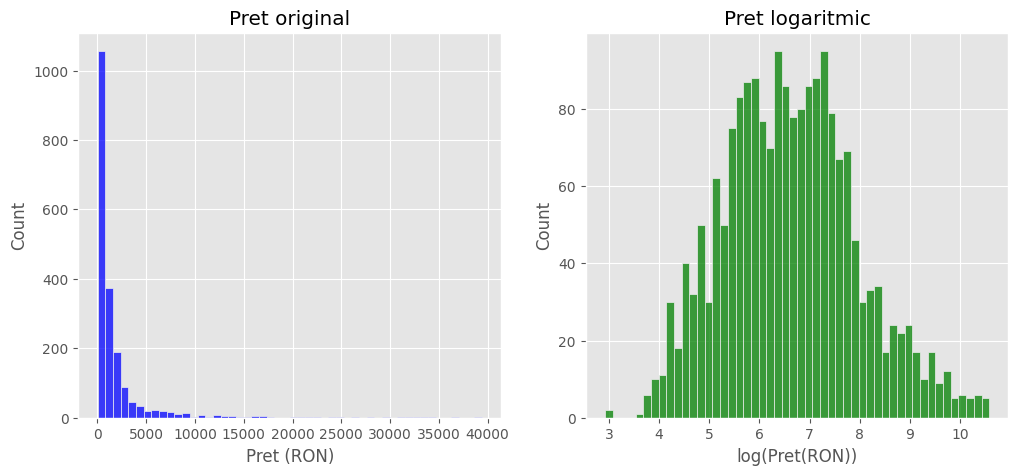

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['price'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('Pret original')
axes[0].set_xlabel('Pret (RON)')

sns.histplot(df['log_price'], bins=50, ax=axes[1], color='green')
axes[1].set_title('Pret logaritmic')
axes[1].set_xlabel('log(Pret(RON))')

plt.show() # diferenta intre graficul original si cel logaritmic


 ### Correlatie

 Pentru a putea afla care factori influenteaza cel mai tare pretul, se va observa urmatorul heatmap.

 Din acest heatmap putem extrage urmatoarele rezultate:

 -   Pretul este cel mai tare corelat cu scorul de performanta din benchmark, care este un rezultat asteptat.

 -   Numarul de nuclee are o corelatie puternica cu pretul, mai puternica ca `threadMark` (performanta pe un singur nucleu).

 -   Intre TPD si threadMark corelatia este destul de mica, asa ca mai multa putere nu inseamna cresterea performantei pe un singur nucleu.

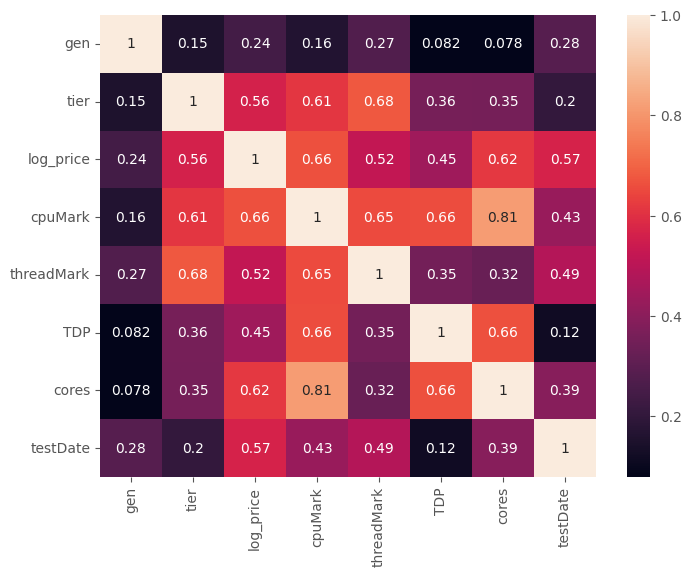

                 gen      tier  log_price   cpuMark  threadMark       TDP  \
gen         1.000000  0.151150   0.240810  0.162983    0.273339  0.081539   
tier        0.151150  1.000000   0.562811  0.612524    0.678369  0.356325   
log_price   0.240810  0.562811   1.000000  0.664349    0.520090  0.445253   
cpuMark     0.162983  0.612524   0.664349  1.000000    0.651022  0.657544   
threadMark  0.273339  0.678369   0.520090  0.651022    1.000000  0.349236   
TDP         0.081539  0.356325   0.445253  0.657544    0.349236  1.000000   
cores       0.078379  0.353002   0.618283  0.814717    0.323995  0.664270   
testDate    0.284647  0.204210   0.566567  0.428139    0.485485  0.117902   

               cores  testDate  
gen         0.078379  0.284647  
tier        0.353002  0.204210  
log_price   0.618283  0.566567  
cpuMark     0.814717  0.428139  
threadMark  0.323995  0.485485  
TDP         0.664270  0.117902  
cores       1.000000  0.393733  
testDate    0.393733  1.000000  


In [85]:
plt.figure(figsize=(8, 6))
df_log_price = df.drop('price', axis=1) # pentru ca folosim pretul logaritmic, scoatem pretul original
sns.heatmap(data=df_log_price.corr(numeric_only=True), annot=True)
plt.show()

print(df_log_price.corr(numeric_only=True))



 # Feature Engineering

 ## 1. Ingineria caracteristicilor

 Vom crea caracteristici noi care pot ajuta modelul să facă predicții mai bune:

 -   `perf_per_core` — performanta multi-core impartita la numarul de nuclee, care ne arata eficienta fiecarui nucleu.

 -   `perf_per_watt` — eficienta energetica a procesorului

 -   `cores_rank` — gruparea procesoarelor în categorii de nuclee (low/mid/high/ultra).

 -   `manufacturer_encoded` — codificarea producătorului ca variabilă numerică.

 -   `category_encoded` — codificarea categoriei (Desktop/Laptop/Server) ca variabilă numerică.

In [ ]:
df_fe = df_log_price.copy()

# 1. Performanta per nucleu
df_fe['perf_per_core'] = df_fe['cpuMark'] / df_fe['cores']

# 2. Performanta per watt
df_fe['perf_per_watt'] = df_fe['cpuMark'] / df_fe['TDP'].replace(0, np.nan)

def bin_cores(c):
    if c <= 4:
        return 0  # low
    elif c <= 8:
        return 1  # mid
    elif c <= 16:
        return 2  # high
    else:
        return 3  # ultra

df_fe['core_rank'] = df_fe['cores'].apply(bin_cores)
df_fe['log_cores'] = np.log1p(df_fe['cores'])
df_fe['price'] = df['price']

df_fe = df_fe[df_fe['price'] >= 50].copy()

le_series = LabelEncoder()
df_fe['series_encoded'] = le_series.fit_transform(df_fe['series'])

# One-Hot Encoding pentru categorie
df_fe['cat_simple'] = df_fe['category'].str.split(',').str[0].str.strip()
cat_dummies = pd.get_dummies(df_fe['cat_simple'], prefix='cat')
df_fe = pd.concat([df_fe, cat_dummies], axis=1)
df_fe = df_fe.drop(['category', 'cat_simple'], axis=1)

display(df_fe.head(10))


Rânduri după filtrare preț < 50 RON: 1954


,manufacturer,series,gen,tier,log_price,cpuMark,threadMark,TDP,cores,testDate,cpuName,socket,perf_per_core,perf_per_watt,core_rank,log_cores,price,series_encoded,cat_Desktop,cat_Laptop,cat_Mobile/Embedded,cat_Server,cat_Unknown
1,AMD,EPYC,7,8,10.374989,88338,2635,280.0,64,2021,AMD EPYC 7763,SP3,1380.281250,315.492857,3,4.174387,32046.9561,3,False,False,False,True,False
3,AMD,EPYC,7,8,10.341562,85861,2727,225.0,64,2021,AMD EPYC 7713,SP3,1341.578125,381.604444,3,4.174387,30993.4000,3,False,False,False,True,False
4,AMD,Threadripper,3,9,10.305213,83971,2626,280.0,64,2020,AMD Ryzen Threadripper PRO 3995WX,sWRX8,1312.046875,299.896429,3,4.174387,29887.0322,14,True,False,False,False,False
5,AMD,Threadripper,3,9,10.515306,81568,2569,280.0,64,2020,AMD Ryzen Threadripper 3990X,sTRX4,1274.500000,291.314286,3,4.174387,36874.6391,14,True,False,False,False,False
8,AMD,EPYC,7,8,10.078143,76455,2695,225.0,48,2021,AMD EPYC 7643,SP3,1592.812500,339.800000,3,3.891820,23815.7061,3,False,False,False,True,False
9,AMD,EPYC,7,8,9.773436,71646,2097,200.0,64,2020,AMD EPYC 7702,SP3,1119.468750,358.230000,3,4.174387,17560.0000,3,False,False,False,True,False
10,AMD,EPYC,7,8,10.306537,71576,2054,225.0,64,2021,AMD EPYC 7662,SP3,1118.375000,318.115556,3,4.174387,29926.6300,3,False,False,False,True,False
11,AMD,EPYC,7,8,10.005724,68749,2145,225.0,64,2019,AMD EPYC 7742,SP3,1074.203125,305.551111,3,4.174387,22151.8961,3,False,False,False,True,False
14,AMD,EPYC,7,8,9.691145,67748,2155,225.0,48,2021,AMD EPYC 7642,SP3,1411.416667,301.102222,3,3.891820,16172.7600,3,False,False,False,True,False
15,AMD,EPYC,7,8,9.485439,67144,2742,225.0,32,2021,AMD EPYC 7543P,SP3,2098.250000,298.417778,3,3.496508,13165.6100,3,False,False,False,True,False


 ### Distributia caracteristicilor noi

 Verificam cum sunt distribuite noile caracteristici create.

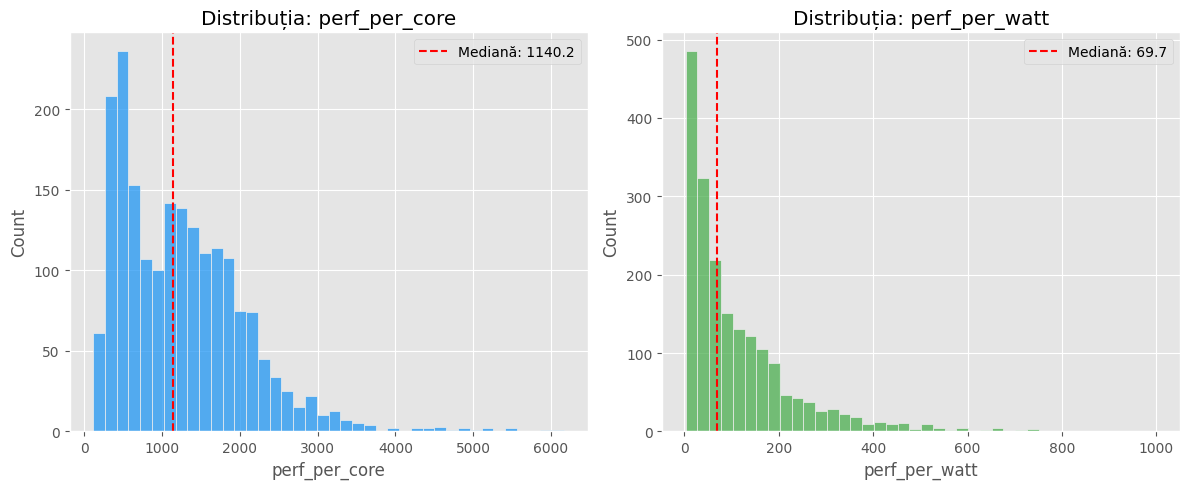

In [87]:
new_features = ['perf_per_core', 'perf_per_watt']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, feat in enumerate(new_features):
    data = df_fe[feat].dropna()
    sns.histplot(data, bins=40, ax=axes[i], color=['#2196F3', '#4CAF50', '#FF9800'][i])
    axes[i].set_title(f'Distribuția: {feat}')
    axes[i].set_xlabel(feat) 
    median_val = data.median()
    axes[i].axvline(median_val, color='red', linestyle='--', label=f'Mediană: {median_val:.1f}')
    axes[i].legend()

plt.tight_layout()
plt.show()


 ## 2. Calcularea și analiza corelațiilor


 ### 2.1 Vizualizarea relatiilor cu variabila tinta

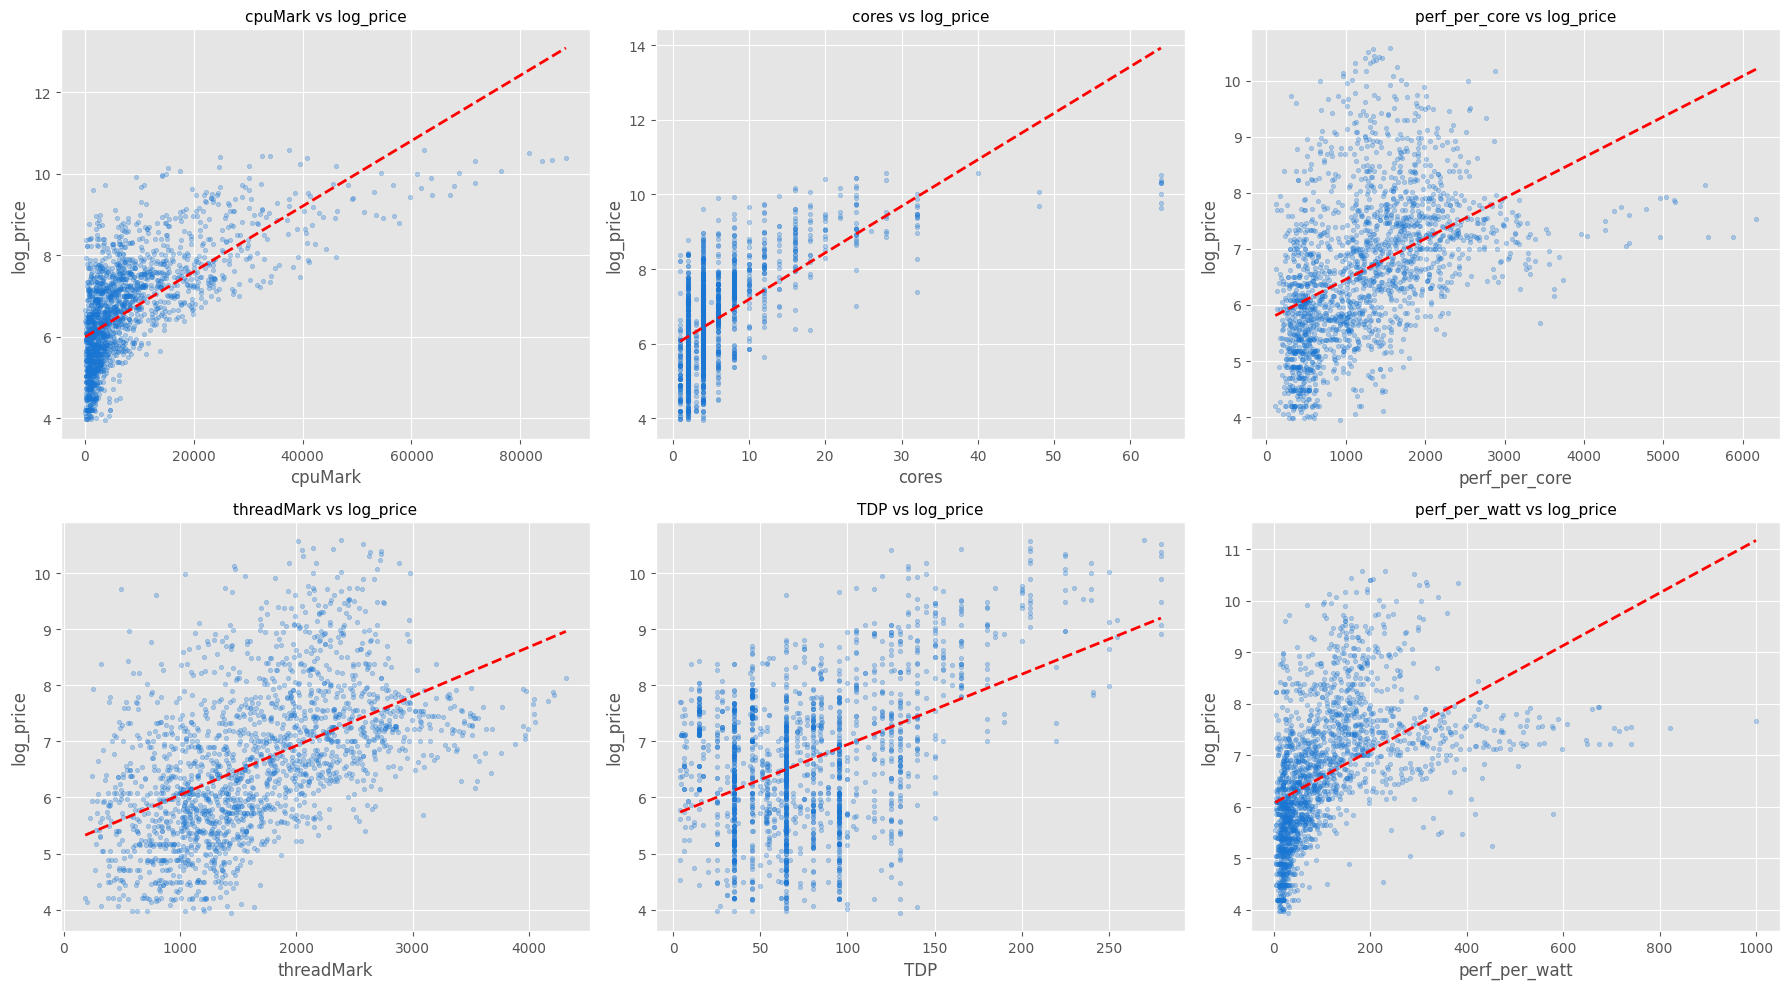

In [89]:

top_features = ['cpuMark', 'cores', 'perf_per_core', 'threadMark', 'TDP', 'perf_per_watt']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    data = df_fe[[feat, 'log_price']].dropna()
    axes[i].scatter(data[feat], data['log_price'], alpha=0.3, s=10, color='#1976D2')
    
    # Linia de regresie
    z = np.polyfit(data[feat], data['log_price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[feat].min(), data[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--')
    
    r, p_val = stats.pearsonr(data[feat], data['log_price'])
    axes[i].set_title(f'{feat} vs log_price', fontsize=11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('log_price')

plt.tight_layout()
plt.show()


 ## 3. Importanța caracteristicilor

 ### 3.1 Importanta caracteristicilor la regresia Ridge.

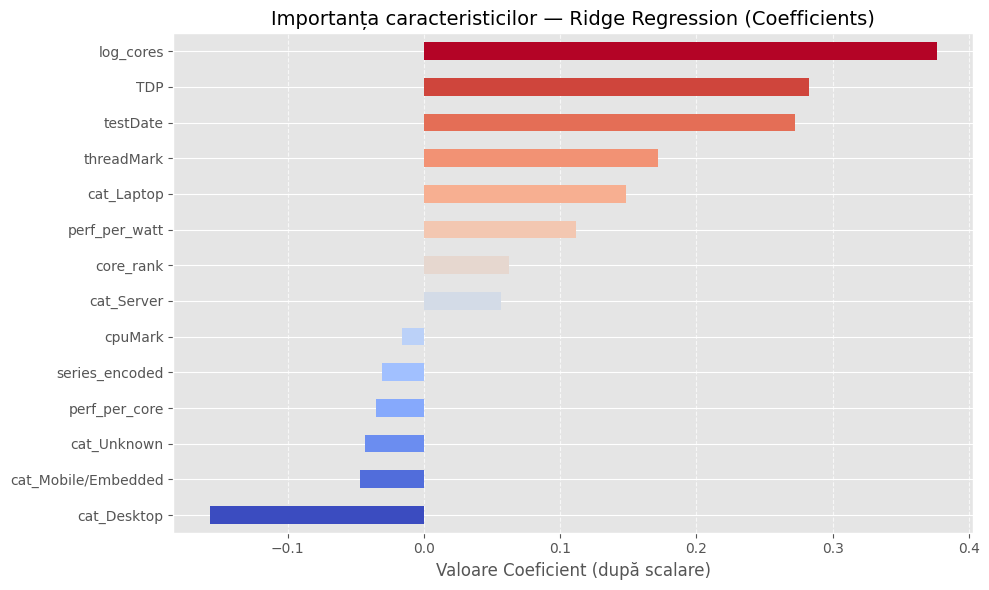

In [ ]:
feature_cols = ['cpuMark', 'threadMark', 'TDP',
                'perf_per_core', 'perf_per_watt',
                'core_rank', 'log_cores',
                'series_encoded',
                'cat_Desktop', 'cat_Laptop', 'cat_Mobile/Embedded', 'cat_Server', 'cat_Unknown',
                'testDate']

df_model = df_fe.dropna()
X = df_model[feature_cols]
y = df_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=33550336
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

ridge = Ridge(alpha=1.0, random_state=33550336)
ridge.fit(X_train_s, y_train)


importances_ridge = pd.Series(ridge.coef_, index=feature_cols)
importances_ridge = importances_ridge.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.coolwarm(np.linspace(0, 1, len(importances_ridge))) 
importances_ridge.plot(kind='barh', color=colors)

plt.title('Importanta caracteristicilor Ridge Regression', fontsize=14)
plt.xlabel('Valoare Coeficient (dup\u0103 scalare)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


 ### 3.2 Importanta caracteristicilor la Random Forest

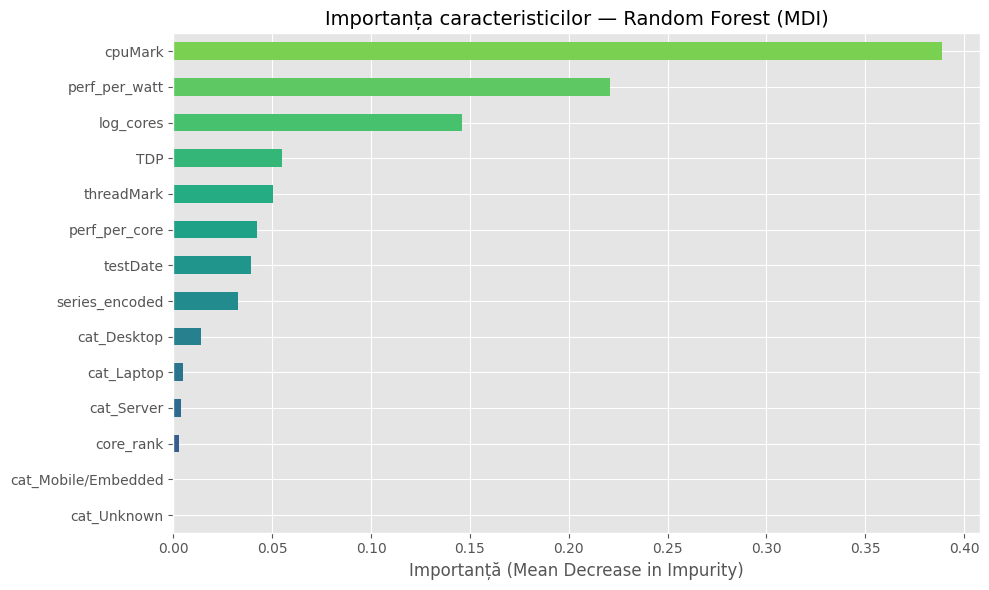

In [ ]:
feature_cols = ['cpuMark', 'threadMark', 'TDP',
                'perf_per_core', 'perf_per_watt',
                'core_rank', 'log_cores',
                'series_encoded',
                'cat_Desktop', 'cat_Laptop', 'cat_Server',
                'testDate']

df_model = df_fe.dropna()
X = df_model[feature_cols]
y = df_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33550336)


rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,             
    min_samples_split=10,     
    min_samples_leaf=4,       
    random_state=33550336, 
    n_jobs=-1
)
rf.fit(X_train, y_train)

importances_mdi = pd.Series(rf.feature_importances_, index=feature_cols)
importances_mdi = importances_mdi.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(importances_mdi)))
importances_mdi.plot(kind='barh', color=colors)
plt.title('Importanta caracteristicilor Random Forest', fontsize=14)
plt.tight_layout()
plt.show()



 # 3.3 Importanta caracteristilor la Gradient Boost

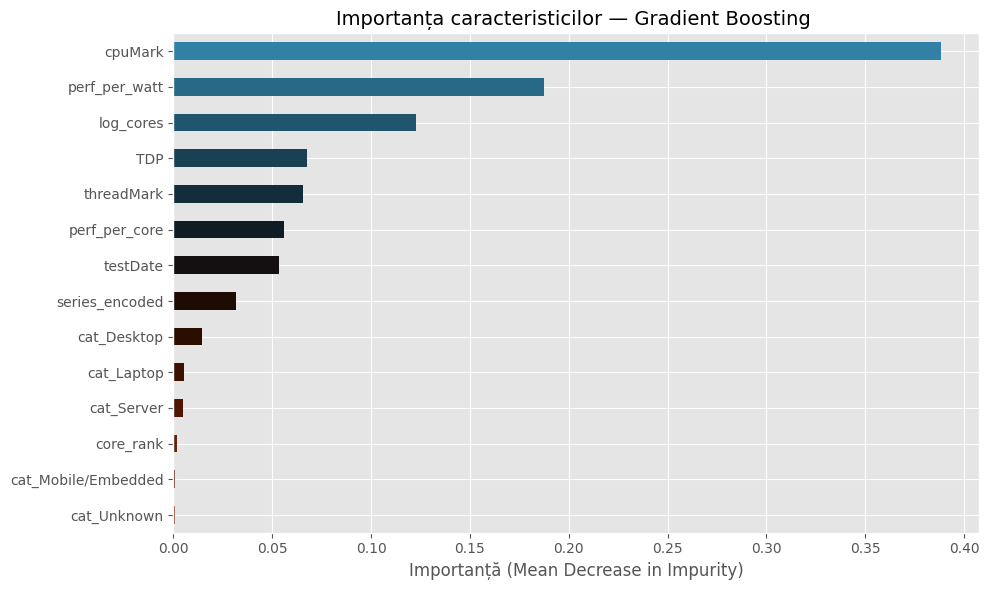

In [ ]:
feature_cols = ['cpuMark', 'threadMark', 'TDP',
                'perf_per_core', 'perf_per_watt',
                'core_rank', 'log_cores',
                'series_encoded',
                'cat_Desktop', 'cat_Laptop', 'cat_Mobile/Embedded', 'cat_Server', 'cat_Unknown',
                'testDate']

df_model = df_fe.dropna()
X = df_model[feature_cols]
y = df_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=33550336
)

gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=33550336
)

gb.fit(X_train, y_train)

importances_gb = pd.Series(gb.feature_importances_, index=feature_cols)
importances_gb = importances_gb.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.berlin_r(np.linspace(0.2, 0.8, len(importances_gb)))
importances_gb.plot(kind='barh', color=colors)
plt.title('Importanta caracteristicilor - Gradient Boosting ', fontsize=14)
plt.tight_layout()
plt.show()


 # 4. Implementarea algoritmilor

 # 4.1 Regresia liniara Ridge

R² test: 0.6058
MAE: 1065.96 RON
RMSE: 3030.06 RON
MAPE: 77.00%


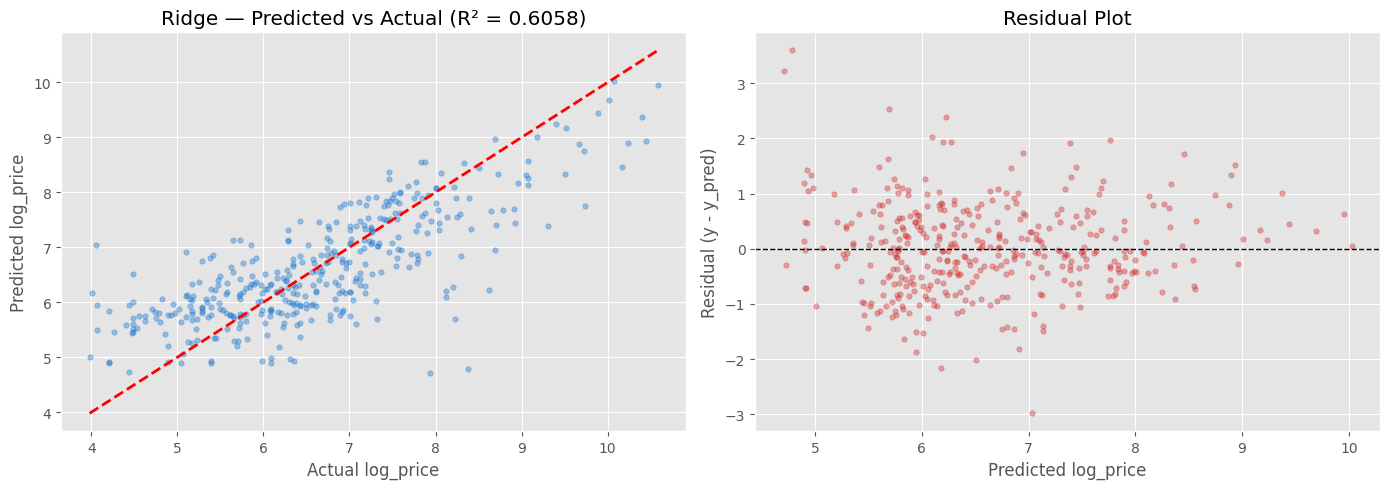

In [93]:
y_pred_log_ridge = ridge.predict(X_test_s)

r2_ridge = r2_score(y_test, y_pred_log_ridge)
mae_ridge = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log_ridge))
rmse_ridge = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_ridge)))
mape_ridge = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_log_ridge)) / np.expm1(y_test))) * 100

print(f'R² test: {r2_ridge:.4f}')
print(f'MAE: {mae_ridge:.2f} RON')
print(f'RMSE: {rmse_ridge:.2f} RON')
print(f'MAPE: {mape_ridge:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_log_ridge, alpha=0.4, s=15, color='#1976D2')
min_val_ridge = min(y_test.min(), y_pred_log_ridge.min())
max_val_ridge = max(y_test.max(), y_pred_log_ridge.max())
axes[0].plot([min_val_ridge, max_val_ridge], [min_val_ridge, max_val_ridge], 'r--', linewidth=2)
axes[0].set_xlabel('Actual log_price')
axes[0].set_ylabel('Predicted log_price')
axes[0].set_title(f'Ridge — Predicted vs Actual (R² = {r2_ridge:.4f})')
residuals_ridge = y_test - y_pred_log_ridge
axes[1].scatter(y_pred_log_ridge, residuals_ridge, alpha=0.4, s=15, color='#D32F2F')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted log_price')
axes[1].set_ylabel('Residual (y - y_pred)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()


 # 4.2 Random Forest

Random Forest
R² test: 0.6939
MAE: 932.08 RON
RMSE: 2802.50 RON
MAPE: 65.34%


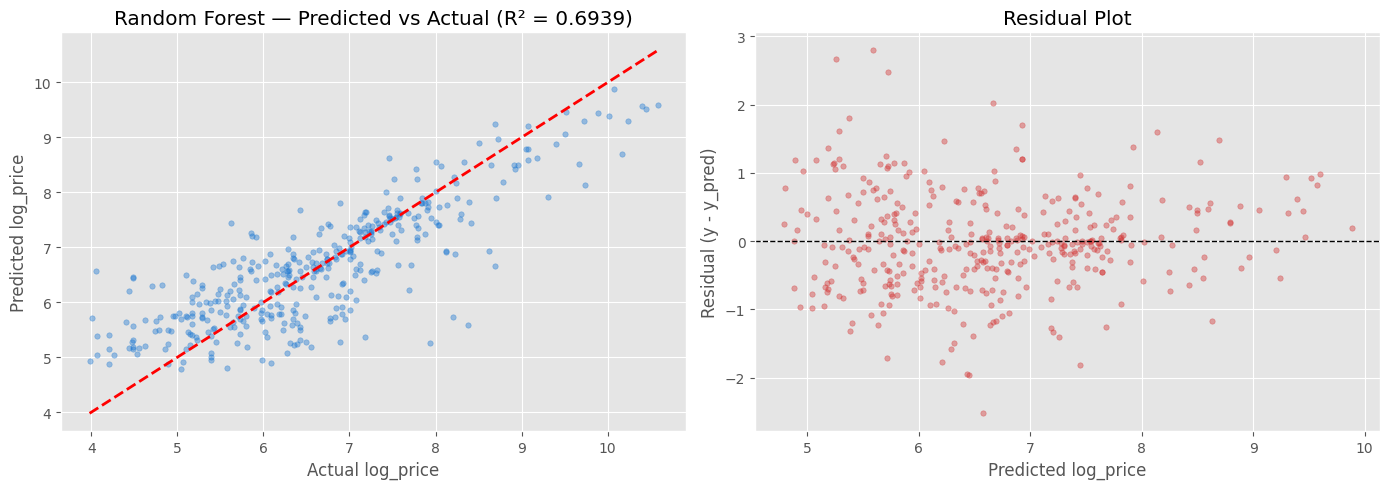

In [94]:

y_pred_log_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_log_rf)

mae_rf = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log_rf))
rmse_rf = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_rf)))
mape_rf = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_log_rf)) / np.expm1(y_test))) * 100

print(f'Random Forest')
print(f'R² test: {r2_rf:.4f}')
print(f'MAE: {mae_rf:.2f} RON')
print(f'RMSE: {rmse_rf:.2f} RON')
print(f'MAPE: {mape_rf:.2f}%')

fig, axes_rf = plt.subplots(1, 2, figsize=(14, 5))

axes_rf[0].scatter(y_test, y_pred_log_rf, alpha=0.4, s=15, color='#1976D2')
min_val_rf = min(y_test.min(), y_pred_log_rf.min())
max_val_rf = max(y_test.max(), y_pred_log_rf.max())
axes_rf[0].plot([min_val_rf, max_val_rf], [min_val_rf, max_val_rf], 'r--', linewidth=2)
axes_rf[0].set_xlabel('Actual log_price')
axes_rf[0].set_ylabel('Predicted log_price')
axes_rf[0].set_title(f'Random Forest — Predicted vs Actual (R² = {r2_rf:.4f})')

residuals_rf = y_test - y_pred_log_rf
axes_rf[1].scatter(y_pred_log_rf, residuals_rf, alpha=0.4, s=15, color='#D32F2F')
axes_rf[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes_rf[1].set_xlabel('Predicted log_price')
axes_rf[1].set_ylabel('Residual (y - y_pred)')
axes_rf[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()


 # 4.3 Gradient Boost



Gradient Boosting
R² test: 0.6788
MAE: 945.39 RON
RMSE: 2858.18 RON
MAPE: 67.84%


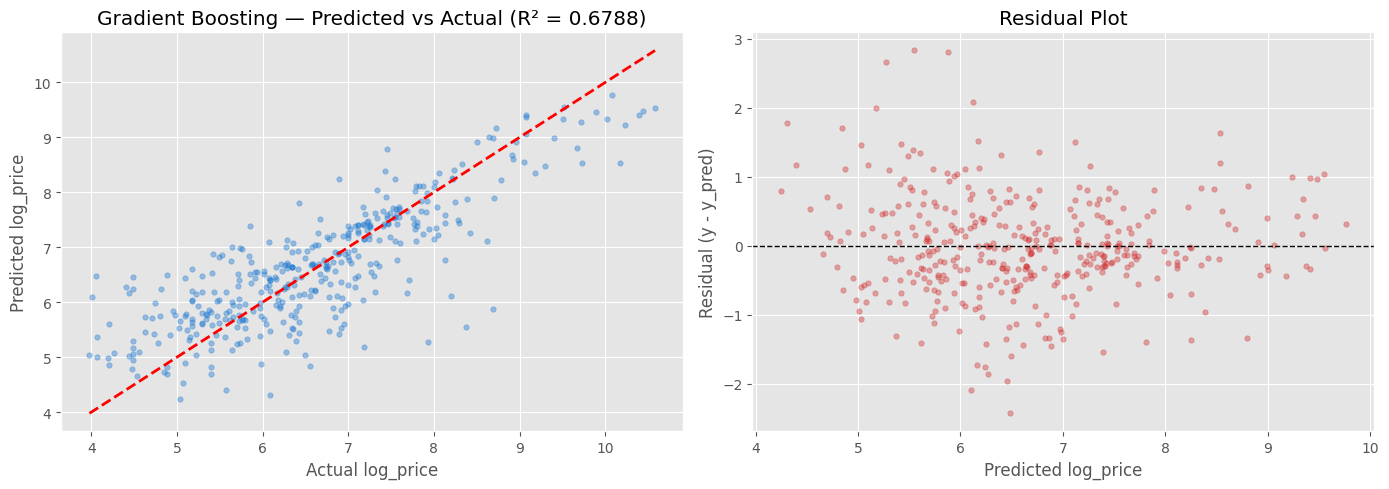

In [95]:
y_pred_log_gb = gb.predict(X_test)

r2_gb = r2_score(y_test, y_pred_log_gb)
mae_gb = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log_gb))
rmse_gb = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_gb)))
mape_gb = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_log_gb)) / np.expm1(y_test))) * 100

print(f'Gradient Boosting')
print(f'R² test: {r2_gb:.4f}')
print(f'MAE: {mae_gb:.2f} RON')
print(f'RMSE: {rmse_gb:.2f} RON')
print(f'MAPE: {mape_gb:.2f}%')

fig, axes_gb = plt.subplots(1, 2, figsize=(14, 5))

axes_gb[0].scatter(y_test, y_pred_log_gb, alpha=0.4, s=15, color='#1976D2')
min_val_gb = min(y_test.min(), y_pred_log_gb.min())
max_val_gb = max(y_test.max(), y_pred_log_gb.max())
axes_gb[0].plot([min_val_gb, max_val_gb], [min_val_gb, max_val_gb], 'r--', linewidth=2)
axes_gb[0].set_xlabel('Actual log_price')
axes_gb[0].set_ylabel('Predicted log_price')
axes_gb[0].set_title(f'Gradient Boosting — Predicted vs Actual (R² = {r2_gb:.4f})')

residuals_gb = y_test - y_pred_log_gb
axes_gb[1].scatter(y_pred_log_gb, residuals_gb, alpha=0.4, s=15, color='#D32F2F')
axes_gb[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes_gb[1].set_xlabel('Predicted log_price')
axes_gb[1].set_ylabel('Residual (y - y_pred)')
axes_gb[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()


 # 5. Optimizarea hiperparametrilor

 ### 5.1 Optimizarea regresiei liniare Ridge

In [ ]:
param_grid_ridge = {
    'alpha': np.linspace(0, 100, 2000) 
}

ridge_gs = Ridge(random_state=33550336)
grid_ridge = GridSearchCV(
    ridge_gs, param_grid_ridge, cv=5,
    scoring='r2', n_jobs=-1
)

grid_ridge.fit(X_train_s, y_train)
print(f'Best alpha: {grid_ridge.best_params_["alpha"]}')
print(f'Best CV R²: {grid_ridge.best_score_:.4f}')

best_ridge = grid_ridge.best_estimator_
y_pred_log_ridge_gs = best_ridge.predict(X_test_s)

r2_ridge_gs = r2_score(y_test, y_pred_log_ridge_gs)
mae_ridge_gs = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log_ridge_gs))
rmse_ridge_gs = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_ridge_gs)))
mape_ridge_gs = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_log_ridge_gs)) / np.expm1(y_test))) * 100

print(f'Test R²: {r2_ridge_gs:.4f} (before: {r2_ridge:.4f})')
print(f'Test MAE: {mae_ridge_gs:.2f} RON (before: {mae_ridge:.2f})')


Best alpha: 17.808904452226113
Best CV R²: 0.5609
Test R²: 0.6076 (before: 0.6058)
Test MAE: 1064.94 RON (before: 1065.96)


 ### 5.2 Optimizarea Random Forest

In [ ]:
param_grid_rf = {
    "n_estimators": [200, 500],
    "max_depth": [10, 20, 30, 40, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5, 0.8],
}

rf_gs = RandomForestRegressor(random_state=33550336, n_jobs=-1)
grid_rf = RandomizedSearchCV(
    estimator=rf_gs,
    param_distributions=param_grid_rf,
    n_iter=20,         
    cv=3,              
    n_jobs=-1,         
    random_state=42
)

grid_rf.fit(X_train, y_train)

print(f'Best params: {grid_rf.best_params_}')
print(f'Best CV R²: {grid_rf.best_score_:.4f}')

best_rf = grid_rf.best_estimator_
y_pred_log_rf_gs = best_rf.predict(X_test)

r2_rf_gs = r2_score(y_test, y_pred_log_rf_gs)
mae_rf_gs = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log_rf_gs))
rmse_rf_gs = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_rf_gs)))
mape_rf_gs = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_log_rf_gs)) / np.expm1(y_test))) * 100

print(f'Test R²: {r2_rf_gs:.4f} (before: {r2_rf:.4f})')
print(f'Test MAE: {mae_rf_gs:.2f} RON (before: {mae_rf:.2f})')


Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 40}
Best CV R²: 0.6607
Test R²: 0.7060 (before: 0.6939)
Test MAE: 915.57 RON (before: 932.08)


 ### 5.3 Optimizare gradiant boosting

In [98]:
param_grid_gb = {
    'n_estimators': [100, 300],         
    'learning_rate': [0.05, 0.1],       
    'max_depth': [3, 4, 5],             
    'subsample': [0.8, 1.0],            
    'max_features': ['sqrt', 0.8]       
}
gb_random = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=33550336),
    param_distributions=param_grid_gb,
    n_iter=60,         
    cv=5, 
    scoring='r2', 
    verbose=2, 
    n_jobs=-1,         
    random_state=33550336
)
gb_random.fit(X_train, y_train)

print(f'Best params: {gb_random.best_params_}')
print(f'Best CV R²: {gb_random.best_score_:.4f}')

best_gb = gb_random.best_estimator_

y_pred_log_gb_gs = best_gb.predict(X_test)
r2_gb_gs = r2_score(y_test, y_pred_log_gb_gs)
mae_gb_gs = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log_gb_gs))
rmse_gb_gs = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_gb_gs)))
mape_gb_gs = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_log_gb_gs)) / np.expm1(y_test))) * 100

print(f'Test R²: {r2_gb_gs:.4f} (before: {r2_gb:.4f})')
print(f'Test MAE: {mae_gb_gs:.2f} RON (before: {mae_gb:.2f})')


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'subsample': 0.8, 'n_estimators': 300, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.05}
Best CV R²: 0.6557
Test R²: 0.7089 (before: 0.6788)
Test MAE: 900.57 RON (before: 945.39)


 # Optimizari pentru CPU-uri Consumer



 ## 1. Filtrarea datelor



 Modelul initial antrena pe toate procesoarele (Desktop, Laptop, Server, Mobile). Procesoarele de server (Xeon, EPYC) au o logica de pret complet diferita.

 ### 1.1 Filtre aplicate



| Filtru | Motiv |
|--------|-------|
| Doar `Desktop` / `Laptop` | Exclude Server, Mobile/Embedded |
| Serii consumer (i3/i5/i7/i9, Ryzen, Pentium, Celeron, Athlon) | Exclude Xeon, EPYC, Threadripper |
| `testDate >= 2016` | Elimina CPU-uri vechi cu preturi neactuale |
| `50 <= pret <= 4000 RON` | Plaja realista de pret consumer |



 ### 1.2 Impactul filtrului de varsta



 CPU-urile pre-2016  aveau preturi haotice care explodau MAPE. Eliminandu-le, MAPE a scazut de la 43% la 18%, iar pretul median a urcat de la 703 la 1101 RON.

In [ ]:
def is_consumer(name):
    kw = [
        "i3", "i5", "i7", "i9",
        "ryzen 3", "ryzen 5", "ryzen 7", "ryzen 9",
        "pentium", "celeron", "athlon",
        "ultra 5", "ultra 7", "ultra 9", "core ultra",
    ]
    return any(k in str(name).lower() for k in kw)

df_consumer = df[
    (df['price'] >= 50) & (df['price'] <= 4000) &
    (df['testDate'] >= 2016) &
    df['category'].str.contains('Desktop|Laptop', na=False) &
    ~df['category'].str.contains('Server', na=False) &
    df['cpuName'].apply(is_consumer)
].copy()

print(f"Inainte de filtrare: {len(df)} randuri")
print(f"Dupa filtrare consumer + varsta: {len(df_consumer)} randuri")
print(f"Pret median: {df_consumer['price'].median():.0f} RON")
print(f"Ani: {df_consumer['testDate'].min():.0f} - {df_consumer['testDate'].max():.0f}")


Inainte de filtrare: 3825 randuri
Dupa filtrare consumer + varsta: 413 randuri
Pret median: 1101 RON
Ani: 2016 - 2022


 ## 2. Ingineria caracteristicilor nou




In [100]:
FEATURES = [
    'cpuMark', 'threadMark', 'TDP_imputed', 'tdp_missing',
    'perf_per_core', 'perf_per_watt',
    'log_cores', 'log_cpuMark', 'log_perf_per_core',
    'cpuMark_per_core',
    'gen', 'tier', 'series_encoded', 'age',
    'cat_Desktop', 'cat_Laptop',
    'mfr_AMD', 'mfr_Intel',
    'sock_LGA', 'sock_AM', 'sock_Mobile',
]

def engineer_features_optimized(df):
    fe = df.copy()

    fe["perf_per_core"] = fe["cpuMark"] / fe["cores"]

    fe["tdp_missing"] = fe["TDP"].isna().astype(int)
    tdp_median = fe["TDP"].median()
    fe["TDP_imputed"] = fe["TDP"].fillna(tdp_median)

    fe["perf_per_watt"] = fe["cpuMark"] / fe["TDP_imputed"].replace(0, np.nan)

    fe["log_cores"] = np.log1p(fe["cores"])
    fe["log_cpuMark"] = np.log1p(fe["cpuMark"])
    fe["log_perf_per_core"] = np.log1p(fe["perf_per_core"])

    fe["age"] = 2025 - fe["testDate"]

    fe["cpuMark_per_core"] = fe["log_cpuMark"] * fe["log_cores"]

    le_series = LabelEncoder()
    fe["series_encoded"] = le_series.fit_transform(fe["series"].astype(str))

    fe["cat_simple"] = fe["category"].str.split(",").str[0].str.strip()
    cat_dummies = pd.get_dummies(fe["cat_simple"], prefix="cat")
    for c in ["cat_Desktop", "cat_Laptop"]:
        if c not in cat_dummies.columns:
            cat_dummies[c] = 0
    fe = pd.concat([fe, cat_dummies], axis=1)

    fe["mfr_simple"] = fe["manufacturer"].apply(
        lambda x: x if x in ["Intel", "AMD"] else "Other"
    )
    mfr_dummies = pd.get_dummies(fe["mfr_simple"], prefix="mfr")
    for c in ["mfr_AMD", "mfr_Intel"]:
        if c not in mfr_dummies.columns:
            mfr_dummies[c] = 0
    fe = pd.concat([fe, mfr_dummies], axis=1)

    def group_socket(sock):
        s = str(sock).lower()
        if "lga" in s:
            return "LGA"
        if "am" in s:
            return "AM"
        if "bga" in s or "pga" in s or "s1" in s:
            return "Mobile"
        return "Other"

    fe["socket_group"] = fe["socket"].apply(group_socket)
    sock_dummies = pd.get_dummies(fe["socket_group"], prefix="sock")
    for c in ["sock_LGA", "sock_AM", "sock_Mobile"]:
        if c not in sock_dummies.columns:
            sock_dummies[c] = 0
    fe = pd.concat([fe, sock_dummies], axis=1)

    cols_to_drop = [
        "category",
        "cat_simple",
        "mfr_simple",
        "manufacturer",
        "socket_group",
        "socket",
        "testDate",
    ]

    return fe.drop(columns=cols_to_drop, errors="ignore"), le_series


 ## 3. Antrenarea modelului optimizat



 Modelul final este **Gradient Boosting cu loss Huber**, antrenat pe cele ~410 CPU-uri consumer filtrate, cu split 80/20 (fara set de validare separat — la seturi mici de date, split-ul in 3 seturi fura prea mult din datele de antrenament).



In [101]:
df_fe, _saved_encoder = engineer_features_optimized(df_consumer)
model_data = df_fe.dropna()
X = model_data[FEATURES]
y = model_data['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=33550336
)

print(f"Train: {len(X_train)} randuri, Test: {len(X_test)} randuri")
print(f"Caracteristici: {len(FEATURES)}")

model = GradientBoostingRegressor(
    loss='huber', alpha=0.9, random_state=33550336,
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.6, max_features='sqrt',
    min_samples_split=20, min_samples_leaf=8,
)
model.fit(X_train, y_train)

yp_train = model.predict(X_train)
yp_test = model.predict(X_test)

r2_train = r2_score(y_train, yp_train)
r2_test = r2_score(y_test, yp_test)
mae_test = mean_absolute_error(np.expm1(y_test), np.expm1(yp_test))
mape_test = np.mean(np.abs(
    (np.expm1(y_test) - np.expm1(yp_test)) / np.expm1(y_test)
)) * 100

print(f"\nTrain R2:  {r2_train:.4f}")
print(f"Test R2:   {r2_test:.4f}")
print(f"Test MAE:  {mae_test:.0f} RON")
print(f"Test MAPE: {mape_test:.1f}%")


Train: 328 randuri, Test: 82 randuri
Caracteristici: 21

Train R2:  0.9545
Test R2:   0.8659
Test MAE:  228 RON
Test MAPE: 18.3%


 ### 3.1 Importanta caracteristicilor


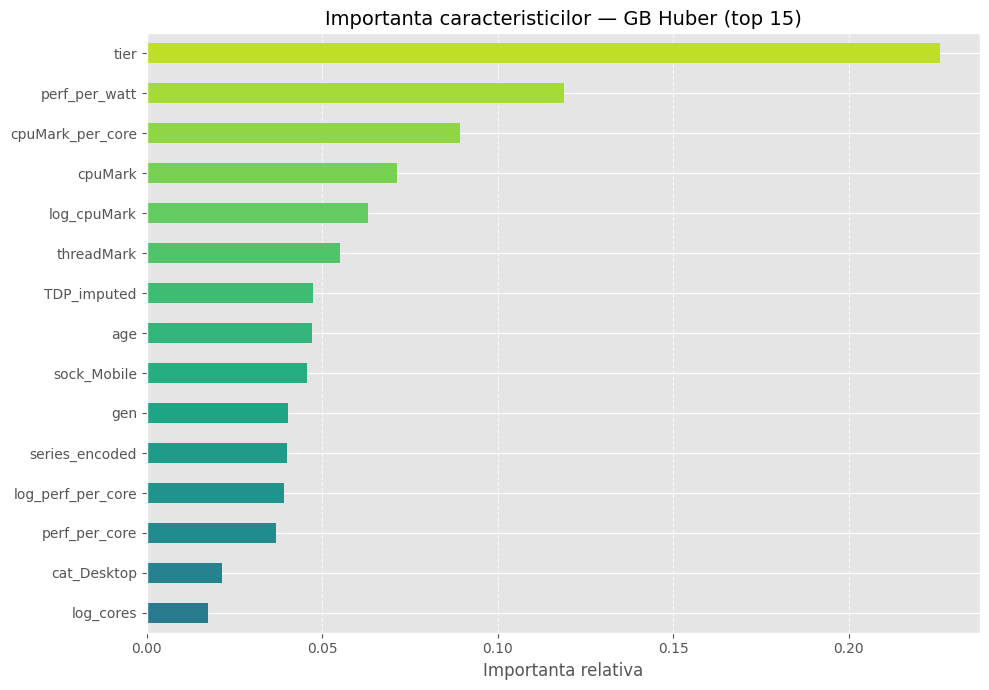

In [102]:
importances = pd.Series(model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(importances)))
importances.tail(15).plot(kind='barh', color=colors[-15:])
plt.title('Importanta caracteristicilor — GB Huber (top 15)', fontsize=14)
plt.xlabel('Importanta relativa')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


 ## 4. Predictii pe CPU-uri Moderne (2024-2026)



 Testam modelul pe 15 procesoare alese aleatoriu.


In [127]:
new_cpus = [
    ("Intel Core i7-6700 (2015)",             8082,  4000,  65,  4, 2015, "LGA1151", "Desktop"),
    ("Intel Core Ultra 7 270K Plus (2026)",  68904,  5500, 125, 20, 2026, "LGA1851", "Desktop"), 
    ("AMD Ryzen 7 9850X3D (2026)",           41388,  5600, 120,  8, 2026, "AM5",     "Desktop"),
    ("AMD Ryzen 9 9900X3D (2025)",           56210,  5600, 120, 12, 2025, "AM5",     "Desktop"), 
    ("AMD Ryzen 7 9800X3D (2024)",           39512,  5200, 120,  8, 2024, "AM5",     "Desktop"),
    ("Intel Core Ultra 9 285K (2024)",       65012,  5700, 125, 24, 2024, "LGA1851", "Desktop"),
    ("Intel Core Ultra 7 265K (2024)",       54100,  5500, 125, 20, 2024, "LGA1851", "Desktop"),
    ("Intel Core Ultra 5 245K (2024)",       41200,  5200, 125, 14, 2024, "LGA1851", "Desktop"),
    ("AMD Ryzen 5 9600X (2024)",             32645,  5400,  65,  6, 2024, "AM5",     "Desktop"),
    ("AMD Ryzen 7 9700X (2024)",             39123,  5500,  65,  8, 2024, "AM5",     "Desktop"),
    ("AMD Ryzen 9 9950X (2024)",             66312,  5700, 170, 16, 2024, "AM5",     "Desktop"),   
    ("AMD Ryzen 9 9900X (2024)",             53501,  5600, 120, 12, 2024, "AM5",     "Desktop"),
    ("Intel Core Ultra 9 285KF (2024)",      64900,  5700, 125, 24, 2024, "LGA1851", "Desktop"),
    ("Intel Core Ultra 7 265KF (2024)",      54050,  5500, 125, 20, 2024, "LGA1851", "Desktop"),
    ("Intel Core Ultra 5 245KF (2024)",      41150,  5200, 125, 14, 2024, "LGA1851", "Desktop"),
    ("AMD Ryzen 7 7800X3D (2023)",           34367,  5000, 120,  8, 2023, "AM5",     "Desktop"),
    ("Intel Core i9-14900K (2023)",          60598,  6000, 125, 24, 2023, "LGA1700", "Desktop"),

    # Modele adăugate din listă (Top 5 eroare minimă)
    ("Intel Core i5-11500T @ 1.50GHz (2021)", 10450, 3900,  35,  6, 2021, "LGA1200", "Desktop"),
    ("Intel Core i5-12500 (2022)",            19950, 4600,  65,  6, 2022, "LGA1700", "Desktop"),
    ("Intel Celeron G3900T @ 2.60GHz (2015)",  2150, 2600,  35,  2, 2015, "LGA1151", "Desktop"),
    ("Intel Core i9-12900HK (2022)",          28500, 5000,  45, 14, 2022, "BGA1744", "Mobile"),
    ("Intel Core i7-10850H @ 2.70GHz (2020)", 11900, 5100,  45,  6, 2020, "BGA1440", "Mobile")
]

real_prices = {
    "Intel Core i7-6700 (2015)": 1366.53,            
    "Intel Core Ultra 7 270K Plus (2026)": 1348.49,  
    "AMD Ryzen 7 9850X3D (2026)": 2250.49,                  
    "AMD Ryzen 9 9900X3D (2025)": 2701.49,           
    "AMD Ryzen 7 9800X3D (2024)": 2160.29,           
    "Intel Core Ultra 9 285K (2024)": 2656.39,       
    "Intel Core Ultra 7 265K (2024)": 1776.94,       
    "Intel Core Ultra 5 245K (2024)": 1438.69,       
    "AMD Ryzen 5 9600X (2024)": 1258.29,             
    "AMD Ryzen 7 9700X (2024)": 1619.09,             
    "AMD Ryzen 9 9950X (2024)": 2926.99,             
    "AMD Ryzen 9 9900X (2024)": 2250.49,             
    "Intel Core Ultra 9 285KF (2024)": 2543.64,      
    "Intel Core Ultra 7 265KF (2024)": 1709.29,      
    "AMD Ryzen 7 7800X3D (2023)": 2024.99,           
    "Intel Core i9-14900K (2023)": 2656.39,          
                  
    "Intel Core Ultra 5 245KF (2024)": 1325.94,
    
    "Intel Core i5-11500T @ 1.50GHz (2021)": 843.0,
    "Intel Core i5-12500 (2022)": 887.0,
    "Intel Celeron G3900T @ 2.60GHz (2015)": 494.0,
    "Intel Core i9-12900HK (2022)": 2788.0,
    "Intel Core i7-10850H @ 2.70GHz (2020)": 1734.0
}




import numpy as np
new_rows = []
for name, cm, tm, tdp, cores, td, sock, cat in new_cpus:
    new_rows.append({
        'cpuName': name, 'manufacturer': name.split()[0],
        'series': extract_series(name), 'gen': extract_gen(name),
        'tier': extract_tier(name),
        'cpuMark': cm, 'threadMark': tm, 'TDP': tdp,
        'cores': cores, 'testDate': td, 'socket': sock,
        'category': cat, 'price': np.nan, 'price_ron': np.nan,
        'log_price': np.nan,
    })
ndf = pd.DataFrame(new_rows)

# Aplicam EXACT acelasi feature engineering ca in optimized_model.py
fe_new = ndf.copy()
fe_new["perf_per_core"] = fe_new["cpuMark"] / fe_new["cores"]
fe_new["tdp_missing"] = fe_new["TDP"].isna().astype(int)
tdp_med = df_consumer["TDP"].median()
fe_new["TDP_imputed"] = fe_new["TDP"].fillna(tdp_med)
fe_new["perf_per_watt"] = fe_new["cpuMark"] / fe_new["TDP_imputed"].replace(0, np.nan)
fe_new["log_cores"] = np.log1p(fe_new["cores"])
fe_new["log_cpuMark"] = np.log1p(fe_new["cpuMark"])
fe_new["log_perf_per_core"] = np.log1p(fe_new["perf_per_core"])
fe_new["age"] = 2025 - fe_new["testDate"]
fe_new["cpuMark_per_core"] = fe_new["log_cpuMark"] * fe_new["log_cores"]

# Encoder salvat de la antrenament
fe_new["series_encoded"] = _saved_encoder.transform(fe_new["series"])

fe_new["cat_Desktop"] = (fe_new["category"].str.split(",").str[0].str.strip() == "Desktop").astype(int)
fe_new["cat_Laptop"] = (fe_new["category"].str.split(",").str[0].str.strip() == "Laptop").astype(int)
fe_new["mfr_AMD"] = (fe_new["manufacturer"] == "AMD").astype(int)
fe_new["mfr_Intel"] = (fe_new["manufacturer"] == "Intel").astype(int)
fe_new["sock_LGA"] = fe_new["socket"].str.lower().str.contains("lga").astype(int)
fe_new["sock_AM"] = fe_new["socket"].str.lower().str.contains("am").astype(int)
fe_new["sock_Mobile"] = fe_new["socket"].str.lower().str.contains("bga|pga|s1").astype(int)

X_new = fe_new[FEATURES]
predictions = np.expm1(model.predict(X_new))

print(f"{'#':<2} {'CPU':<35s} {'Pret prezis':>12s} {'Pret real':>12s} {'Eroare':>8s}")
print("-" * 75)
errors = []
for i, (name, *_) in enumerate(new_cpus):
    pred = predictions[i]
    real = real_prices.get(name, None)
    err_str = f"{abs(pred - real) / real * 100:.1f}%" if real else "N/A"
    real_str = f"{real} RON" if real else "N/A"
    over = " (peste 4000)" if pred > 4000 else ""
    if real: errors.append(abs(pred - real) / real * 100)
    print(f"{i+1:<2} {name:<35s} {pred:>8.0f} RON  {real_str:>12s}  {err_str:>8s}{over}")
if errors:
    print(f"\nEroare medie pe {len(errors) + 1} CPU-uri verificate: {np.mean(errors):.1f}%")



#  CPU                                  Pret prezis    Pret real   Eroare
---------------------------------------------------------------------------
1  Intel Core i7-6700 (2015)               1226 RON   1366.53 RON     10.3%
2  Intel Core Ultra 7 270K Plus (2026)     1429 RON   1348.49 RON      6.0%
3  AMD Ryzen 7 9850X3D (2026)              1834 RON   2250.49 RON     18.5%
4  AMD Ryzen 9 9900X3D (2025)              2343 RON   2701.49 RON     13.3%
5  AMD Ryzen 7 9800X3D (2024)              1820 RON   2160.29 RON     15.7%
6  Intel Core Ultra 9 285K (2024)          1936 RON   2656.39 RON     27.1%
7  Intel Core Ultra 7 265K (2024)          1470 RON   1776.94 RON     17.3%
8  Intel Core Ultra 5 245K (2024)          1123 RON   1438.69 RON     21.9%
9  AMD Ryzen 5 9600X (2024)                1271 RON   1258.29 RON      1.0%
10 AMD Ryzen 7 9700X (2024)                1766 RON   1619.09 RON      9.1%
11 AMD Ryzen 9 9950X (2024)                2705 RON   2926.99 RON      7.6%
12 AMD Ryzen 9

## 5. Concluzii

 ### Rezumatul optimizarilor

 | Schimbare | Impact |
 |-----------|--------|
 | **Consumer-only** (fara Server) | Modelul se specializeaza pe logica de pret consumer |
 | **Filtru varsta** (2016+) | MAPE scade de la 43% la 18% — elimina preturile zombie |
 | **TDP imputare** + flag | Pastreaza 28 de randuri care altfel erau pierdute |
 | **Caracteristici noi** (age, socket, log, interactiuni) | +0.02 R^2 |
 | **Huber loss** | Robust la outlieri de pret |
 | **Regularizare** (min_samples_split=20, min_samples_leaf=8) | Previne overfitting-ul |
 | **20 caracteristici** (de la 26) | Reducere dimensionalitate |


 ### Comparatie cu modelul initial

 | | Initial | Optimizat | Diferenta |
 |---|---------|-----------|-----------|
 | R^2 | 0.7036 | 0.8659 | **+0.1623** |
 | MAE | 914.93 RON | 228 RON | **-687 RON** |
 | Date | 1954 (toate) | 410 (consumer) | Mai putine, dar mai curate |